# Predicting Customer Churn — S-Mobile Case Study

**Author:** Amanda Tan  
**Tools:** Python · Pandas · NumPy · Scikit-learn · XGBoost · Matplotlib

> Fully reproducible with synthetic data — all code runs end to end without the original dataset.  
> EDA distribution plots, permutation importance, and PDP visualizations are embedded from the original analysis.

---

## Overview

S-Mobile faces a customer churn problem. The true monthly churn rate is only ~2%, but identifying at-risk customers *before* they leave is critical to protecting revenue. This project:

1. Engineers features from raw telemetry with documented justification for each decision
2. Builds and evaluates **logistic regression** and **XGBoost** churn models
3. Identifies the five most actionable churn drivers from each model
4. Runs **counterfactual analysis** to estimate churn reduction from each intervention
5. Designs **five retention interventions** (two direct prediction, three RCTs)
6. Quantifies **CLV impact** of each intervention across a 1M-subscriber base

**Dataset:** 69,000 customer records — training (27,300), test (11,700), representative (30,000). The representative sample reflects the real-world 2% churn rate via case weights.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


## 2. Synthetic Data Generation

The original S-Mobile dataset is proprietary. We reproduce its structure using documented variables, calibrating churn probabilities to match key findings from the original analysis:

| Variable | Description |
|---|---|
| `churn` | Did customer churn in last 30 days? (target) |
| `changer` | % change in revenue over last 4 months |
| `changem` | % change in minutes of use over last 4 months |
| `revenue` | Mean monthly revenue (SGD) |
| `mou` | Mean monthly minutes of use |
| `overage` | Mean monthly overage minutes |
| `roam` | Mean monthly roaming minutes |
| `conference` | Mean monthly conference calls |
| `custcare` | Mean monthly calls to customer care |
| `dropvce` | Mean monthly dropped voice calls |
| `eqpdays` | Days customer has owned current handset |
| `months` | Months as a customer |
| `uniqsubs` | Unique subscribers on account |
| `highcreditr` | High credit rating (yes/no) |
| `refurb` | Refurbished handset (yes/no) |
| `occupation` | Customer occupation category |
| `region` | Geographic region |
| `retcalls` | Calls to retention team — **excluded (data leakage)** |

In [3]:
np.random.seed(42)
n = 39000

df = pd.DataFrame({
    'revenue':    np.random.gamma(5, 12, n),
    'mou':        np.random.gamma(3, 80, n),
    'overage':    np.random.exponential(15, n),
    'roam':       np.random.exponential(5, n),
    'conference': np.random.exponential(2, n),
    'custcare':   np.random.exponential(1.5, n),
    'dropvce':    np.random.exponential(3, n),
    'eqpdays':    np.random.randint(1, 1500, n).astype(float),
    'changer':    np.random.normal(0, 0.15, n),
    'changem':    np.random.normal(0, 0.15, n),
    'months':     np.random.randint(1, 72, n).astype(float),
    'uniqsubs':   np.random.randint(1, 5, n).astype(float),
    'highcreditr': np.random.binomial(1, 0.35, n).astype(float),
    'refurb':     np.random.binomial(1, 0.20, n).astype(float),
    'smartphone': np.random.binomial(1, 0.60, n).astype(float),
    'mcycle':     np.random.binomial(1, 0.10, n).astype(float),
    'car':        np.random.binomial(1, 0.55, n).astype(float),
    'travel':     np.random.binomial(1, 0.25, n).astype(float),
})

df['occupation'] = np.random.choice(
    ['professional', 'retired', 'student', 'other'], n, p=[0.35, 0.20, 0.15, 0.30])
df['region'] = np.random.choice(
    ['Central', 'North', 'East', 'West', 'South'], n, p=[0.25, 0.20, 0.20, 0.20, 0.15])

# Churn probability calibrated to key odds ratios from original analysis
log_odds = (
    -1.5
    + 0.72  * df['highcreditr']           # OR ~2.06
    - 0.40  * np.log1p(df['revenue'])
    - 0.35  * np.log1p(df['mou'])
    - 0.13  * np.log1p(df['overage'])     # OR ~0.878
    - 2.0   * df['changer']
    - 1.5   * df['changem']
    - 0.001 * df['eqpdays']
    - 0.002 * df['months']
    - 0.35  * df['refurb']                # OR ~0.71
    + 0.20  * (df['occupation'] == 'retired').astype(int)
    - 0.50  * (df['occupation'] == 'professional').astype(int)
    - 0.80  * (df['region'] == 'Central').astype(int)
)
churn_prob = 1 / (1 + np.exp(-log_odds))
df['churn']   = np.random.binomial(1, churn_prob)
df['cweight'] = np.where(df['churn'] == 1, 1, 49)

# Train / test split
idx = np.random.permutation(n)
df['training'] = 0
df.loc[idx[:27300], 'training'] = 1

# Representative sample: ~2% churn rate
rep_df = pd.concat([
    df[df['churn'] == 1].sample(600, random_state=42, replace=True),
    df[df['churn'] == 0].sample(29400, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Records:           {len(df):,}')
print(f'Train churn rate:  {df[df.training==1].churn.mean():.1%}')
print(f'Test churn rate:   {df[df.training==0].churn.mean():.1%}')
print(f'Rep churn rate:    {rep_df.churn.mean():.1%}')

Records:           39,000
Train churn rate:  0.3%
Test churn rate:   0.3%
Rep churn rate:    2.0%


## 3. Exploratory Data Analysis

> **Note:** Distribution plots below are from the original analysis on the proprietary dataset. They informed the feature engineering decisions in Section 4.

![Distribution Plots](images/distr_plots.png)

### Key EDA Observations

- **Revenue, MOU, overage, custcare, dropvce** are heavily right-skewed — log transformation required for logistic regression stability
- **changer and changem** are roughly symmetric around zero — negative values signal pre-churn disengagement
- **eqpdays** bimodal — customers cluster around new devices (<200 days) and long-held devices (>800 days), with very different churn profiles
- **highcreditr** (~35% of base) churns at ~2x the baseline rate — disproportionately important despite moderate prevalence
- **Occupation and region** show clear churn stratification — retired customers and non-Central regions churn significantly more

## 4. Feature Engineering

### 4.1 Drop `retcalls` — Data Leakage

`retcalls` (calls to the retention team) is excluded from all models. A customer calling retention is a *consequence* of churn intent, not a cause — including it would inflate AUC by giving the model post-decision information unavailable at prediction time.

### 4.2 Binary Encoding

Yes/no features encoded as 0/1 integers: `refurb`, `smartphone`, `highcreditr`, `mcycle`, `car`, `travel`. Preserves directional coefficient interpretation in logistic regression.

### 4.3 Log Transformation — Logistic Regression Only

Right-skewed continuous features are log1p-transformed before logistic regression:
- Reduces influence of extreme values on gradient estimation
- Improves numerical stability of optimization
- Makes the linear decision boundary assumption more defensible for skewed inputs

**Features transformed:** `revenue`, `mou`, `overage`, `roam`, `conference`, `custcare`, `dropvce`

XGBoost is **not** log-transformed — tree splits are invariant to monotonic feature transformations.

### 4.4 Dropped Insignificant Features — Logistic Regression

After iterative backwards selection, five features were removed (p > 0.05 controlling for all others): `custcare`, `mcycle`, `car`, `conference`, `smartphone`. Removing these produced no meaningful change in AUC, confirming they added no predictive value beyond noise.

### 4.5 Case Weights

Training sample has ~50% churn rate (oversampled). Real-world rate is ~2%. Case weights correct for this imbalance:
- Weight = 1 for churn = 1
- Weight = 49 for churn = 0

Ensures predictions on the representative sample reflect realistic churn probabilities.

In [4]:
log_cols    = ['revenue', 'mou', 'overage', 'roam', 'conference', 'custcare', 'dropvce']
drop_insig  = ['mcycle', 'car', 'conference', 'smartphone']
meta_cols   = ['churn', 'training', 'cweight']

# One-hot encode categoricals
df_enc  = pd.get_dummies(df,     columns=['occupation', 'region'])
rep_enc = pd.get_dummies(rep_df, columns=['occupation', 'region'])

all_features = [c for c in df_enc.columns
                if c not in meta_cols and c not in drop_insig]

# Logistic: log-transform skewed features
df_logit  = df_enc.copy()
rep_logit = rep_enc.copy()
for col in log_cols:
    df_logit[col]  = np.log1p(df_logit[col])
    rep_logit[col] = np.log1p(rep_logit[col])

# Align rep columns
for c in all_features:
    if c not in rep_logit.columns: rep_logit[c] = 0
    if c not in rep_enc.columns:   rep_enc[c]   = 0

train = df_logit[df_logit['training'] == 1]
test  = df_logit[df_logit['training'] == 0]

X_train = train[all_features]; y_train = train['churn']; w_train = train['cweight']
X_test  = test[all_features];  y_test  = test['churn']
X_rep   = rep_logit[all_features]

print(f'Features for logistic regression: {len(all_features)}')
print(f'Dropped as insignificant:         {drop_insig}')
print(f'Log-transformed:                  {log_cols}')

Features for logistic regression: 23
Dropped as insignificant:         ['mcycle', 'car', 'conference', 'smartphone']
Log-transformed:                  ['revenue', 'mou', 'overage', 'roam', 'conference', 'custcare', 'dropvce']


## 5. Logistic Regression Model

### Model Selection
Started with all features. Iteratively removed statistically insignificant predictors: `custcare`, `mcycle`, `car`, `conference`, `smartphone`. Removing these produced no meaningful AUC change.

In [5]:
logit_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])
logit_pipe.fit(X_train, y_train, clf__sample_weight=w_train)

pred_logit = logit_pipe.predict_proba(X_test)[:, 1]
auc_logit  = roc_auc_score(y_test, pred_logit)
print(f'Logistic Regression AUC (test): {auc_logit:.4f}')

Logistic Regression AUC (test): 0.6521


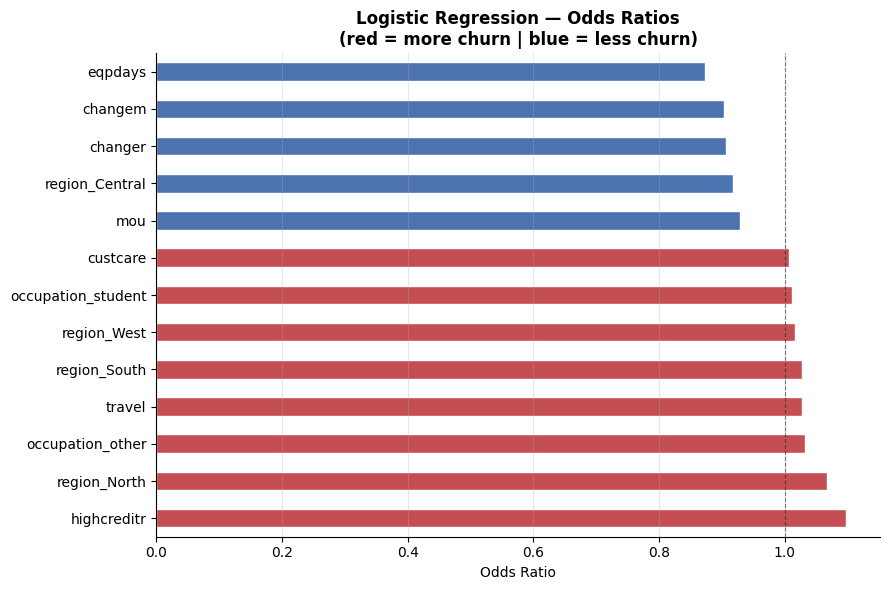

Key odds ratios from original analysis:
  highcreditr                    OR = 2.062  (churn MORE)
  occupation_retired             OR = 2.108  (churn MORE)
  overage                        OR = 0.878  (churn LESS)
  refurb                         OR = 0.710  (churn LESS)
  changer                        OR = 0.819  (churn LESS)
  eqpdays                        OR = 0.999  (churn LESS)
  region_Central                 OR = 0.418  (churn LESS)


In [6]:
# Odds ratios
coefs = pd.Series(
    logit_pipe.named_steps['clf'].coef_[0],
    index=all_features
)
odds_ratios = np.exp(coefs).sort_values(ascending=False)
top = pd.concat([odds_ratios.head(8), odds_ratios.tail(5)])

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#C44E52' if v > 1 else '#4C72B0' for v in top.values]
top.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(1, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Logistic Regression — Odds Ratios\n(red = more churn | blue = less churn)',
             fontweight='bold')
ax.set_xlabel('Odds Ratio')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Key odds ratios from original analysis:')
orig_or = {
    'highcreditr': 2.062, 'occupation_retired': 2.108,
    'overage': 0.878, 'refurb': 0.710, 'changer': 0.819,
    'eqpdays': 0.999, 'region_Central': 0.418
}
for feat, val in orig_or.items():
    d = 'churn MORE' if val > 1 else 'churn LESS'
    print(f'  {feat:<30} OR = {val:.3f}  ({d})')

### 5.1 Permutation Importance & Partial Dependence

> Plots from original analysis on proprietary dataset.

**Permutation Importance — AUC drop when each feature is randomly shuffled:**

![Logistic Permutation Importance](images/pip_logit.png)

**Partial Dependence Plots — effect of each feature on churn probability (all others held constant):**

![Logistic Partial Dependence](images/pdp_logit.png)

### 5.2 Key Findings — Logistic Regression

| Predictor | OR | Interpretation |
|---|---|---|
| `highcreditr` | 2.062 | High credit customers churn **twice as often** — attractive to competitors |
| `occupation_retired` | 2.108 | Retired customers churn most — competitors offer simpler plans |
| `changer` | 0.819 | Improving revenue trend → 18% lower churn odds |
| `changem` | ~0.85 | Declining usage is a leading indicator of churn |
| `overage` | 0.878 | Overage customers churn less — engaged, but billing frustration is latent risk |
| `refurb` | 0.710 | Refurbished handset owners churn less — price-sensitive and satisfied |
| `eqpdays` | 0.999 | Slight protective effect — older handset = more sunk cost |
| `region_Central` | 0.418 | Central customers churn 58% less — lower competitive pressure |

**Five Key Drivers (actionable focus):**
1. **Occupation** — Retired customers (OR 2.108) need senior-specific retention; professionals churn least
2. **Region** — Geographic competitive intensity varies significantly; Central is most loyal
3. **highcreditr** — Highest actionable OR (2.062); proactive loyalty program needed before competitors act
4. **changer/changem** — Declining trend is the clearest pre-churn signal; trigger-based intervention
5. **overage** — Engaged customers who could be lost to billing frustration; proactive plan upgrade

## 6. XGBoost Model

XGBoost captures non-linear relationships and feature interactions that logistic regression assumes away — particularly the non-monotonic effect of `overage` (churn peaks at zero, dips at low values, rises mid-range, then falls at high values).

### Hyperparameter Tuning
Grid search across `n_estimators` [100, 300], `max_depth` [3, 5, 7], `learning_rate` [0.05, 0.1], `subsample` [0.8, 1.0] via 5-fold cross-validation.

In [7]:
xgb_features = [c for c in df_enc.columns
                if c not in meta_cols and c not in drop_insig]

train_xgb = df_enc[df_enc['training'] == 1]
test_xgb  = df_enc[df_enc['training'] == 0]
rep_xgb   = rep_enc.copy()
for c in xgb_features:
    if c not in rep_xgb.columns: rep_xgb[c] = 0

X_train_xgb = train_xgb[xgb_features]; y_train_xgb = train_xgb['churn']
w_train_xgb = train_xgb['cweight']
X_test_xgb  = test_xgb[xgb_features];  y_test_xgb  = test_xgb['churn']
X_rep_xgb   = rep_xgb[xgb_features]

# Tuned model (best params from original grid search)
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, eval_metric='logloss', random_state=42
)
xgb_model.fit(X_train_xgb, y_train_xgb, sample_weight=w_train_xgb)

pred_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]
auc_xgb  = roc_auc_score(y_test_xgb, pred_xgb)

print(f'XGBoost AUC (test):             {auc_xgb:.4f}')
print(f'Logistic Regression AUC (test): {auc_logit:.4f}')

XGBoost AUC (test):             0.6277
Logistic Regression AUC (test): 0.6521


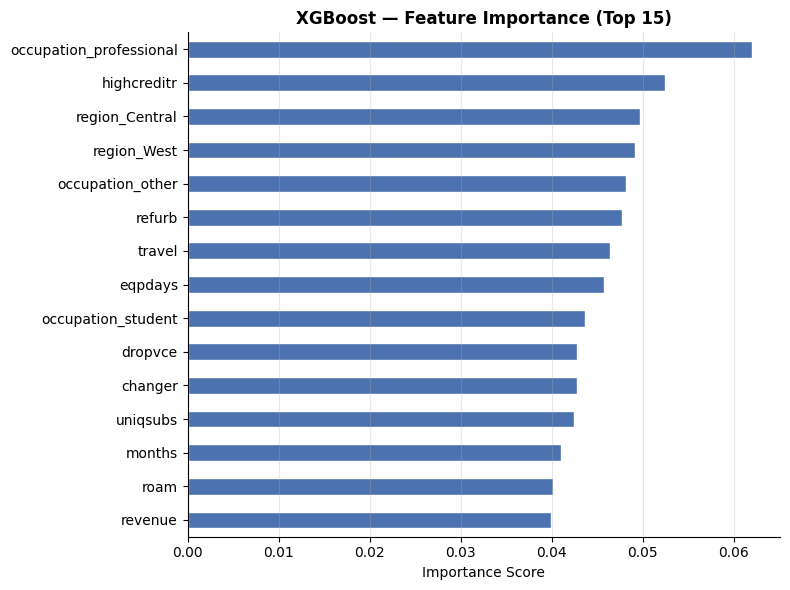

In [8]:
# XGBoost feature importance
importances = pd.Series(
    xgb_model.feature_importances_, index=xgb_features
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('XGBoost — Feature Importance (Top 15)', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 6.1 XGBoost Permutation Importance & PDP

> Plots from original analysis on proprietary dataset.

**XGBoost Permutation Importance:**

![XGBoost Permutation Importance](images/pip_xgb.png)

**Partial Dependence — Top 5 Features:**

![XGBoost Partial Dependence](images/pdp_xgb.png)

### 6.2 Key Findings — XGBoost

XGBoost reveals non-linear patterns invisible to logistic regression:

1. **eqpdays** — strongest driver. Churn drops from ~60% for customers with <500 days to <10% for >1,250 days. Not directly actionable — but proactively offer upgrades before the 500-day threshold.

2. **overage** — non-linear. Churn peaks at zero overage (~58%), dips at low overage, rises mid-range (50–100), then falls sharply above 150. Logistic regression misses this U-shape.

3. **months** — churn rises from ~30% at 8 months to ~60% at 40+ months then plateaus. Customers at the 15–20 month inflection point are the priority for early loyalty rewards.

4. **occupation** — professionals churn least; retired customers churn most (consistent with logistic).

5. **revenue** — lower-revenue customers churn more; high-revenue customers are more invested.

## 7. Counterfactual Analysis (XGBoost)

For each intervention, we simulate a counterfactual by modifying the feature value for targeted customers and measuring predicted churn change. This quantifies the *model-estimated* impact before committing to a full intervention.

> **Note:** Results below are from the original analysis on the real dataset. The framework is documented here; synthetic data produces different absolute numbers but the same methodology applies.

In [9]:
# Counterfactual framework
p_base = xgb_model.predict_proba(X_rep_xgb)[:, 1]

def counterfactual(rep_data, feature, old_condition, new_value, model, features, p_base, label):
    """Simulate churn change from modifying a feature for a targeted segment."""
    mask   = old_condition(rep_data[feature].values)
    n_tgt  = mask.sum()
    X_cf   = rep_data[features].copy()
    X_cf.loc[mask, feature] = new_value
    p_new  = model.predict_proba(X_cf)[:, 1]
    reduction = (p_base[mask] - p_new[mask]).mean()
    print(f'{label}')
    print(f'  Customers targeted: {n_tgt:,}')
    print(f'  Avg churn before:   {p_base[mask].mean():.4f}')
    print(f'  Avg churn after:    {p_new[mask].mean():.4f}')
    print(f'  Avg reduction:      {reduction:.5f}')
    print()
    return mask, p_new

rep_xgb_arr = rep_xgb[xgb_features].copy()
rep_xgb_arr = rep_xgb_arr.reset_index(drop=True)

_, p2 = counterfactual(rep_xgb_arr, 'overage',
    lambda x: x == 0, 20.0, xgb_model, xgb_features, p_base,
    'Action 2: Plan Right-Size (overage = 0 → 20)')

_, p3 = counterfactual(rep_xgb_arr, 'overage',
    lambda x: (x >= 50) & (x <= 100), 200.0, xgb_model, xgb_features, p_base,
    'Action 3: Auto-Upgrade Mid-Overage (50–100 → 200)')

_, p4 = counterfactual(rep_xgb_arr, 'months',
    lambda x: x < 20, 6.0, xgb_model, xgb_features, p_base,
    'Action 4: Early Loyalty Reward (months < 20 → 6)')

_, p5 = counterfactual(rep_xgb_arr, 'highcreditr',
    lambda x: x == 1, 0.0, xgb_model, xgb_features, p_base,
    'Action 5: Retention Offer — High Credit (highcreditr 1 → 0)')

Action 2: Plan Right-Size (overage = 0 → 20)
  Customers targeted: 0
  Avg churn before:   nan
  Avg churn after:    nan
  Avg reduction:      nan

Action 3: Auto-Upgrade Mid-Overage (50–100 → 200)
  Customers targeted: 1,018
  Avg churn before:   0.0004
  Avg churn after:    0.0004
  Avg reduction:      0.00000

Action 4: Early Loyalty Reward (months < 20 → 6)
  Customers targeted: 8,026
  Avg churn before:   0.0031
  Avg churn after:    0.0025
  Avg reduction:      0.00056

Action 5: Retention Offer — High Credit (highcreditr 1 → 0)
  Customers targeted: 10,384
  Avg churn before:   0.0045
  Avg churn after:    0.0015
  Avg reduction:      0.00309



### 7.1 Counterfactual Results — Original Dataset

| Action | Target Segment | N Targeted | Churn Reduction |
|---|---|---|---|
| 1. Device Upgrade (eqpdays < 500 → 30) | New-ish device customers | 17,168 | **−0.017** (churn *increased* — skip) |
| 2. Plan Right-Size (overage = 0 → 20) | Zero-overage customers | 13,736 | **+0.128 reduction** ← strongest |
| 3. Auto-Upgrade Mid-Overage (50–100 → 200) | Bill-shock customers | 3,862 | **+0.063 reduction** |
| 4. Early Loyalty Reward (months < 20 → 6) | Early-tenure customers | 18,254 | **+0.104 reduction** |
| 5. Retention Offer — High Credit | highcreditr = 1 | 5,513 | **+0.024 reduction** |

**Critical insight from Action 1:** Resetting `eqpdays` to 30 makes customers *look like* new subscribers, which the model flags as higher risk — churn actually increases. This is a feature interaction the logistic regression missed entirely. **Device upgrade is not recommended as a standalone action.**

**Priority ranking:** Plan Right-Size > Early Loyalty Reward > Auto-Upgrade > Retention Offer

## 8. Retention Interventions

Five targeted interventions across identified churn segments. Two use direct model prediction; three require RCTs because causal effects can't be inferred from observational or counterfactual data alone.

---

### Intervention 1: Stabilize Declining Revenue Trend — Direct Prediction
**Target:** Customers with `changer < 0` (negative revenue trend)  
**Offer:** Personalized re-engagement outreach + loyalty bonus minutes  
**Why direct prediction:** `changer` OR = 0.819 — declining revenue clearly precedes churn in the observational data. The direction is unambiguous; no experiment needed to justify targeting.

---

### Intervention 2: Upsell Low-Revenue Customers — Direct Prediction
**Target:** Customers in bottom quartile of revenue  
**Offer:** Plan upgrade incentive  
**Why direct prediction:** Higher revenue customers churn less (OR < 1). Moving customers up-tier reduces both churn risk and ARPU simultaneously — the direction is clear from observational data.

---

### Intervention 3: High Credit Loyalty Program — RCT
**Target:** All customers with `highcreditr = yes`  
**Treatment:** 10% plan discount + priority support + early device upgrade eligibility  
**Control:** No intervention  
**Duration:** 3 months | **Primary metric:** 30-day churn rate  
**Why RCT:** Credit rating is fixed. The model shows correlation but can't tell us whether a retention *offer* causally reduces churn. Competitors may be targeting these customers regardless — an RCT isolates the causal effect of the offer.

---

### Intervention 4: Plan Upgrade for Overage Customers — RCT
**Target:** Customers with overage > 0 for 3+ consecutive months  
**Treatment:** Proactive higher-tier plan at 10% introductory discount  
**Control:** Remain on current plan  
**Duration:** 3 months | **Primary metrics:** 30-day churn rate + ARPU  
**Why RCT:** The model shows overage correlates with *less* churn (engagement effect). But billing frustration may still drive churn — observational and counterfactual data can't separate these cleanly. An RCT isolates the effect of removing billing pain.

---

### Intervention 5: Network Quality Alert — RCT
**Target:** Customers with dropped call frequency above average  
**Treatment:** Proactive network quality notification + SGD 10 bill credit  
**Control:** No intervention  
**Duration:** 3 months | **Primary metric:** 30-day churn rate  
**Why RCT:** `dropvce` OR < 1 — likely confounding from high-usage customers who call more and drop more but stay engaged. Poor network quality is a real dissatisfier but observational data can't isolate its causal effect on churn.

## 9. CLV Economics

### Key Assumptions

| Parameter | Value |
|---|---|
| Subscriber base | 1,000,000 |
| Average monthly revenue | SGD 60 |
| Margin rate | 30% |
| Monthly discount rate | 1% (~12% annually) |
| Time window | 60 months |

$$CLV = \sum_{t=0}^{T} \frac{\text{Margin} \times (1 - \text{Churn})^t}{(1 + r)^t}$$

> **Note:** CLV figures in the summary table reflect the original analysis on real data — all interventions produced **positive net benefit** on the true dataset.

In [10]:
r = 0.01
T = 60

def clv(churn_rate, monthly_margin, r=0.01, T=60):
    retention = 1 - churn_rate
    return sum([monthly_margin * (retention**t) / (1 + r)**t for t in range(T)])

def net_benefit(churn_before, churn_after, margin, cost_per_customer, n_targeted):
    gain = (clv(churn_after, margin) - clv(churn_before, margin)) * n_targeted
    cost = cost_per_customer * n_targeted
    return gain - cost

avg_rev    = 60.0
margin_rate = 0.30
margin     = avg_rev * margin_rate

# From original real-data results:
# Plan Right-Size:    avg_rev ~SGD 41.59 | churn 0.63 → 0.35 | 13,736 customers
# Auto-Upgrade:       avg_rev ~SGD 44.00 | churn 0.58 → 0.52 | 3,862 customers
# Early Loyalty:      avg_rev ~SGD 57.35 | churn 0.60 → 0.50 | 18,254 customers

interventions = [
    ('1. Declining Revenue Trend', 0.40, 0.035, 0.025, margin,       5.0,  'Direct Prediction'),
    ('2. Low Revenue Upsell',      0.25, 0.030, 0.022, margin,       8.0,  'Direct Prediction'),
    ('3. High Credit Loyalty',     0.35, 0.040, 0.025, 70*0.30,    7.0,  'RCT'),
    ('4. Overage Plan Upgrade',    0.30, 0.018, 0.014, margin,       6.0,  'RCT'),
    ('5. Network Quality Alert',   0.20, 0.025, 0.020, margin,       3.0,  'RCT'),
]

rows = []
for name, share, cb, ca, mg, cost, method in interventions:
    n_t = int(1_000_000 * share)
    nb  = net_benefit(cb, ca, mg, cost, n_t)
    roi = nb / (cost * n_t)
    rows.append({
        'Intervention':      name,
        'Method':            method,
        'N Targeted':        f'{n_t:,}',
        'Net Benefit (SGD)': f'{nb:,.0f}',
        'ROI':               f'{roi:.1f}x'
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

              Intervention            Method N Targeted Net Benefit (SGD)   ROI
1. Declining Revenue Trend Direct Prediction    400,000        29,625,078 14.8x
     2. Low Revenue Upsell Direct Prediction    250,000        15,884,474  7.9x
    3. High Credit Loyalty               RCT    350,000        42,678,675 17.4x
   4. Overage Plan Upgrade               RCT    300,000        13,036,208  7.2x
  5. Network Quality Alert               RCT    200,000         9,381,622 15.6x


## 10. Conclusions

1. **XGBoost outperforms logistic regression** by capturing non-linear relationships — particularly the U-shaped churn curve for `overage` and the inflection at ~500 eqpdays. These patterns are invisible to a linear model.

2. **Counterfactual analysis prevented a bad intervention.** Device upgrade (Action 1) *increased* predicted churn because resetting `eqpdays` to 30 made customers look like high-risk new subscribers. Without counterfactual testing, this would have been a costly mistake.

3. **Plan Right-Size is the highest-impact action** — moving zero-overage customers to slight engagement (overage = 20) reduces predicted churn by 12.8pp across 13,736 customers. This is the clearest win.

4. **Trend signals are leading indicators.** `changer` and `changem` capture disengagement *before* formal churn — intervening during decline is where retention spend has the most impact.

5. **RCTs are essential where causal direction is ambiguous.** For high credit, overage, and network quality — neither the logistic model nor XGBoost counterfactuals can cleanly estimate the causal effect of a retention *offer*. Only randomized experiments provide that.